# 05 Anomaly Detection (Isolation Forest)

This notebook detects unusual customer behavior using Isolation Forest.

**Input:**
- `outputs/customer_features.csv`
- `outputs/X_scaled.npy`
- `outputs/final_customer_clusters.csv` (optional)

**Output:**
- `outputs/anomaly_scores.csv`
- `outputs/anomaly_summary.csv`
- `outputs/final_customer_clusters_with_anomalies.csv`

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)
RANDOM_STATE = 42

In [2]:
BASE_DIR = Path.cwd()
OUTPUT_DIR = BASE_DIR / "outputs"

customer_path = OUTPUT_DIR / "customer_features.csv"
X_scaled_path = OUTPUT_DIR / "X_scaled.npy"
clustered_path = OUTPUT_DIR / "final_customer_clusters.csv"

print("customer exists:", customer_path.exists())
print("X_scaled exists:", X_scaled_path.exists())
print("clustered exists:", clustered_path.exists())

customer exists: True
X_scaled exists: True
clustered exists: True


In [3]:
customer = pd.read_csv(customer_path)
X_scaled = np.load(X_scaled_path)

if clustered_path.exists():
    clustered = pd.read_csv(clustered_path)
    # prefer clustered table as base because it has selected model labels
    if "customer_id" in clustered.columns and "customer_id" in customer.columns:
        base = clustered.merge(customer, on="customer_id", how="left", suffixes=("", "_feat"))
    else:
        base = clustered.copy()
else:
    base = customer.copy()

print("Base shape:", base.shape)
base.head()

Base shape: (1000, 29)


,customer_id,frequency_count,monetary_total,avg_order_value,weekend_ratio,lunch_ratio,snacks_ratio,dinner_ratio,last_date,recency_days,avg_customer_age,dominant_gender,cluster_kmeans,cluster_dbscan,cluster_gmm,cluster_hierarchical,selected_model,cluster_label,frequency_count_feat,monetary_total_feat,avg_order_value_feat,weekend_ratio_feat,lunch_ratio_feat,snacks_ratio_feat,dinner_ratio_feat,last_date_feat,recency_days_feat,avg_customer_age_feat,dominant_gender_feat
0,CUST1001,1,34,34.0,1.0,1.0,0.0,0.0,2024-01-07 19:17:00,173,38.0,M,2,-1,2,4,KMeans,2,1,34,34.0,1.0,1.0,0.0,0.0,2024-01-07 19:17:00,173,38.0,M
1,CUST1002,1,142,142.0,0.0,1.0,0.0,0.0,2024-01-09 08:05:00,172,36.0,F,2,0,2,0,KMeans,2,1,142,142.0,0.0,1.0,0.0,0.0,2024-01-09 08:05:00,172,36.0,F
2,CUST1003,1,105,105.0,0.0,1.0,0.0,0.0,2024-06-27 14:21:00,2,42.0,M,2,0,2,0,KMeans,2,1,105,105.0,0.0,1.0,0.0,0.0,2024-06-27 14:21:00,2,42.0,M
3,CUST1004,1,85,85.0,0.0,0.0,0.0,1.0,2024-03-29 17:16:00,92,21.0,F,1,1,1,1,KMeans,1,1,85,85.0,0.0,0.0,0.0,1.0,2024-03-29 17:16:00,92,21.0,F
4,CUST1005,1,205,205.0,1.0,0.0,1.0,0.0,2024-06-29 09:02:00,0,36.0,M,4,-1,4,3,KMeans,4,1,205,205.0,1.0,0.0,1.0,0.0,2024-06-29 09:02:00,0,36.0,M


In [4]:
# Train Isolation Forest
contamination = 0.04  # expected anomaly share; tune if needed
iso = IsolationForest(
    n_estimators=300,
    contamination=contamination,
    random_state=RANDOM_STATE,
)

iso.fit(X_scaled)
pred = iso.predict(X_scaled)  # -1 anomaly, 1 normal
score = iso.decision_function(X_scaled)  # lower => more anomalous

base["anomaly_flag"] = (pred == -1).astype(int)
base["anomaly_score"] = score

print("Total rows:", len(base))
print("Anomalies detected:", int(base["anomaly_flag"].sum()))

Total rows: 1000
Anomalies detected: 40


In [5]:
# Rank most anomalous customers
sort_cols = ["anomaly_score"]
if "monetary_total" in base.columns:
    sort_cols.append("monetary_total")

anomaly_top = base.sort_values(sort_cols, ascending=[True] + [False] * (len(sort_cols) - 1)).head(25)
anomaly_top

,customer_id,frequency_count,monetary_total,avg_order_value,weekend_ratio,lunch_ratio,snacks_ratio,dinner_ratio,last_date,recency_days,avg_customer_age,dominant_gender,cluster_kmeans,cluster_dbscan,cluster_gmm,cluster_hierarchical,selected_model,cluster_label,frequency_count_feat,monetary_total_feat,avg_order_value_feat,weekend_ratio_feat,lunch_ratio_feat,snacks_ratio_feat,dinner_ratio_feat,last_date_feat,recency_days_feat,avg_customer_age_feat,dominant_gender_feat,anomaly_flag,anomaly_score
721,CUST1722,1,505,505.0,1.0,1.0,0.0,0.0,2024-06-23 19:22:00,5,42.0,F,3,-1,2,2,KMeans,3,1,505,505.0,1.0,1.0,0.0,0.0,2024-06-23 19:22:00,5,42.0,F,1,-0.095197
321,CUST1322,1,499,499.0,1.0,1.0,0.0,0.0,2024-06-02 20:00:00,26,22.0,M,3,-1,2,2,KMeans,3,1,499,499.0,1.0,1.0,0.0,0.0,2024-06-02 20:00:00,26,22.0,M,1,-0.084193
869,CUST1870,1,510,510.0,0.0,0.0,1.0,0.0,2024-05-16 09:00:00,44,44.0,M,4,-1,0,2,KMeans,4,1,510,510.0,0.0,0.0,1.0,0.0,2024-05-16 09:00:00,44,44.0,M,1,-0.084100
672,CUST1673,1,437,437.0,1.0,0.0,0.0,1.0,2024-04-27 19:25:00,62,38.0,F,3,-1,1,2,KMeans,3,1,437,437.0,1.0,0.0,0.0,1.0,2024-04-27 19:25:00,62,38.0,F,1,-0.074723
441,CUST1442,1,514,514.0,0.0,1.0,0.0,0.0,2024-05-20 16:07:00,40,23.0,M,3,-1,2,2,KMeans,3,1,514,514.0,0.0,1.0,0.0,0.0,2024-05-20 16:07:00,40,23.0,M,1,-0.060278
882,CUST1883,1,442,442.0,1.0,1.0,0.0,0.0,2024-06-02 10:43:00,27,31.0,F,3,-1,2,2,KMeans,3,1,442,442.0,1.0,1.0,0.0,0.0,2024-06-02 10:43:00,27,31.0,F,1,-0.053552
416,CUST1417,1,431,431.0,1.0,1.0,0.0,0.0,2024-05-18 08:54:00,42,37.0,M,3,-1,2,2,KMeans,3,1,431,431.0,1.0,1.0,0.0,0.0,2024-05-18 08:54:00,42,37.0,M,1,-0.044612
177,CUST1178,1,340,340.0,1.0,0.0,1.0,0.0,2024-06-29 11:44:00,0,42.0,F,4,-1,4,2,KMeans,4,1,340,340.0,1.0,0.0,1.0,0.0,2024-06-29 11:44:00,0,42.0,F,1,-0.043728
410,CUST1411,1,400,400.0,1.0,0.0,1.0,0.0,2024-04-14 16:06:00,76,26.0,M,4,-1,4,2,KMeans,4,1,400,400.0,1.0,0.0,1.0,0.0,2024-04-14 16:06:00,76,26.0,M,1,-0.037778
360,CUST1361,1,410,410.0,0.0,1.0,0.0,0.0,2024-05-21 18:13:00,38,44.0,F,3,-1,2,2,KMeans,3,1,410,410.0,0.0,1.0,0.0,0.0,2024-05-21 18:13:00,38,44.0,F,1,-0.035349


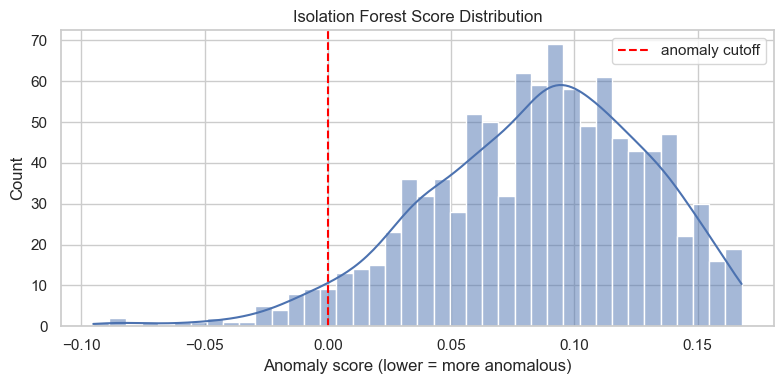

In [6]:
# Score distribution
plt.figure(figsize=(8, 4))
sns.histplot(base["anomaly_score"], bins=40, kde=True)
plt.axvline(base.loc[base["anomaly_flag"] == 1, "anomaly_score"].max(), color="red", linestyle="--", label="anomaly cutoff")
plt.title("Isolation Forest Score Distribution")
plt.xlabel("Anomaly score (lower = more anomalous)")
plt.legend()
plt.tight_layout()
plt.show()

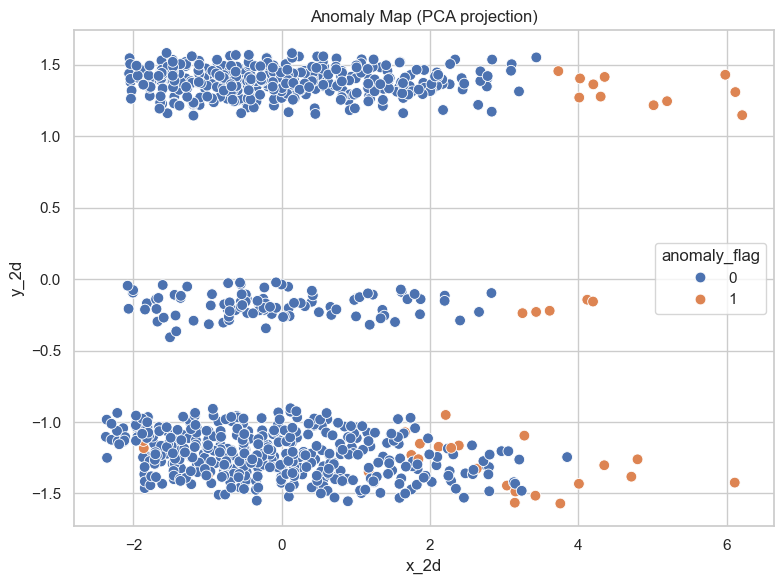

In [7]:
# 2D visualization with anomaly highlight
pca = PCA(n_components=2, random_state=RANDOM_STATE)
xy = pca.fit_transform(X_scaled)

plot_df = base.copy()
plot_df["x_2d"] = xy[:, 0]
plot_df["y_2d"] = xy[:, 1]

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=plot_df,
    x="x_2d",
    y="y_2d",
    hue="anomaly_flag",
    palette={0: "#4C72B0", 1: "#DD8452"},
    s=60,
)
plt.title("Anomaly Map (PCA projection)")
plt.tight_layout()
plt.show()

,cluster_label,customers,anomalies,anomaly_rate
0,0,163,1,0.006135
1,1,222,11,0.049550
2,2,375,0,0.000000
3,3,158,18,0.113924
4,4,82,10,0.121951


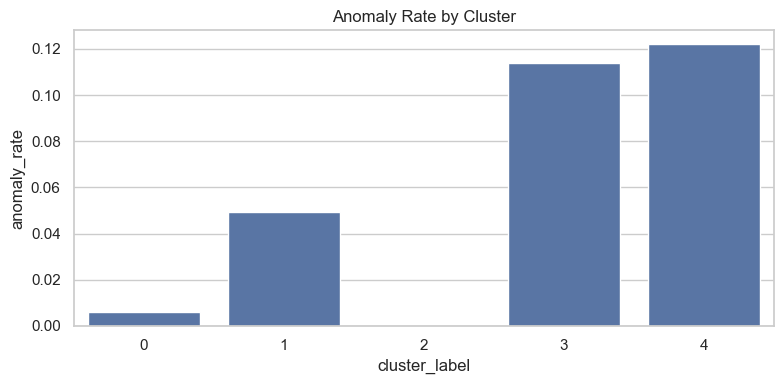

In [8]:
# Optional: anomaly rate by cluster if cluster_label exists
if "cluster_label" in base.columns:
    cluster_anom = base.groupby("cluster_label").agg(
        customers=("customer_id", "count"),
        anomalies=("anomaly_flag", "sum"),
        anomaly_rate=("anomaly_flag", "mean"),
    ).reset_index()
    display(cluster_anom)

    plt.figure(figsize=(8, 4))
    sns.barplot(data=cluster_anom, x="cluster_label", y="anomaly_rate")
    plt.title("Anomaly Rate by Cluster")
    plt.tight_layout()
    plt.show()
else:
    print("cluster_label not available; skipping cluster-wise anomaly analysis.")

In [9]:
# Save artifacts
anom_cols = [c for c in ["customer_id", "anomaly_flag", "anomaly_score", "cluster_label", "selected_model"] if c in base.columns]
anomaly_scores = base[anom_cols].copy()

anomaly_scores_path = OUTPUT_DIR / "anomaly_scores.csv"
anomaly_scores.to_csv(anomaly_scores_path, index=False)

anomaly_summary = pd.DataFrame([
    {
        "total_records": int(len(base)),
        "anomaly_count": int(base["anomaly_flag"].sum()),
        "anomaly_rate": float(base["anomaly_flag"].mean()),
        "score_min": float(base["anomaly_score"].min()),
        "score_max": float(base["anomaly_score"].max()),
        "score_mean": float(base["anomaly_score"].mean()),
    }
])
anomaly_summary_path = OUTPUT_DIR / "anomaly_summary.csv"
anomaly_summary.to_csv(anomaly_summary_path, index=False)

final_with_anom_path = OUTPUT_DIR / "final_customer_clusters_with_anomalies.csv"
base.to_csv(final_with_anom_path, index=False)

print("Saved:")
print("-", anomaly_scores_path)
print("-", anomaly_summary_path)
print("-", final_with_anom_path)
anomaly_summary

Saved:
- S:\cafeteria\cafeteria-iq\backend\notebooks\outputs\anomaly_scores.csv
- S:\cafeteria\cafeteria-iq\backend\notebooks\outputs\anomaly_summary.csv
- S:\cafeteria\cafeteria-iq\backend\notebooks\outputs\final_customer_clusters_with_anomalies.csv


,total_records,anomaly_count,anomaly_rate,score_min,score_max,score_mean
0,1000,40,0.04,-0.095197,0.167788,0.084914


## Viva Notes

You can explain anomaly detection as:
- Isolation Forest learns normal customer behavior patterns.
- Points isolated quickly in random trees are treated as anomalies.
- I used anomaly score and anomaly rate analysis to identify unusual spending/visit behavior.
- The output can be used for fraud checks, campaign targeting, or operational alerts.

## Next Notebook

Continue with `06_association_rules_apriori.ipynb` to discover item combinations and recommendation opportunities.